# Notebook 04 — Modeling

**Project:** Credit Risk Analytics — Horizon Lending Inc.  
**Author:** Senior Data Scientist  
**Date:** July 2026  

---

## Objective

Train, evaluate, compare, and select the best model for predicting loan default.

The best model is saved for Business Simulation and Explainability.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score)
import lightgbm as lgb

try:
    import xgboost as xgb
    XGB_OK = True
except (ImportError, OSError):
    xgb = None; XGB_OK = False
    print("Note: XGBoost unavailable. Using LightGBM.")

np.random.seed(42)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
D = lambda p: os.path.join(ROOT, p)
os.makedirs(D("models"), exist_ok=True)
os.makedirs(D("reports/figures"), exist_ok=True)
print("Setup complete.")

Setup complete.


In [2]:
X = pd.read_parquet(D("data/processed/X_features.parquet"))
y = pd.read_parquet(D("data/processed/y_target.parquet"))["TARGET"]
print(f"Loaded: X={X.shape}, y={y.shape}, default={y.mean():.2%}")

for col in X.select_dtypes(include=["object","string","category"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)
print(f"Features: {X.shape[1]}, NaN: {X.isnull().sum().sum()}")

Loaded: X=(307511, 182), y=(307511,), default=8.07%
Features: 182, NaN: 0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train: {X_train.shape} default={y_train.mean():.2%}")
print(f"Test:  {X_test.shape}  default={y_test.mean():.2%}")

Train: (246008, 182) default=8.07%
Test:  (61503, 182)  default=8.07%


---
## 4. Train Models

In [4]:
print("Logistic Regression...", end=" ")
lr = LogisticRegression(C=0.1, solver="saga", class_weight="balanced",
    max_iter=10000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
p_lr = lr.predict_proba(X_test)[:, 1]
print(f"AUC={roc_auc_score(y_test, p_lr):.4f}")

Logistic Regression... 

AUC=0.7483


In [5]:
print("Decision Tree...", end=" ")
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
    class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)
p_dt = dt.predict_proba(X_test)[:, 1]
print(f"AUC={roc_auc_score(y_test, p_dt):.4f}")

Decision Tree... 

AUC=0.7231


In [6]:
print("Random Forest...", end=" ")
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
    min_samples_leaf=20, class_weight="balanced_subsample",
    random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]
print(f"AUC={roc_auc_score(y_test, p_rf):.4f}")

Random Forest... 

AUC=0.7464


In [7]:
if XGB_OK:
    print("XGBoost...", end=" ")
    sw = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_m = xgb.XGBClassifier(n_estimators=500, max_depth=6,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=sw, eval_metric="auc",
        early_stopping_rounds=50, random_state=42,
        verbosity=0, n_jobs=-1)
    xgb_m.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    p_xgb = xgb_m.predict_proba(X_test)[:, 1]
    print(f"AUC={roc_auc_score(y_test, p_xgb):.4f}")
else:
    xgb_m = None; p_xgb = None
    print("XGBoost skipped.")

XGBoost... 

AUC=0.7668


In [8]:
print("LightGBM...", end=" ")
lgb_m = lgb.LGBMClassifier(n_estimators=500, num_leaves=31,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", metric="auc",
    early_stopping_rounds=50, random_state=42,
    verbose=-1, n_jobs=-1)
lgb_m.fit(X_train, y_train, eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
p_lgb = lgb_m.predict_proba(X_test)[:, 1]
print(f"AUC={roc_auc_score(y_test, p_lgb):.4f}")

LightGBM... 

Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[326]	valid_0's auc: 0.768039
AUC=0.7680


---
## 5. Evaluation

In [9]:
def score_model(name, proba):
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    yb = (proba >= 0.5).astype(int)
    p = precision_score(y_test, yb, zero_division=0)
    r = recall_score(y_test, yb, zero_division=0)
    f1 = f1_score(y_test, yb, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, yb).ravel()
    return {"Model":name,"AUC":auc,"AP":ap,"P":p,"R":r,"F1":f1,
            "TP":tp,"FP":fp,"FN":fn,"TN":tn}

rows = [score_model("LogReg", p_lr), score_model("DT", p_dt),
        score_model("RF", p_rf)]
if XGB_OK:
    rows.append(score_model("XGBoost", p_xgb))
rows.append(score_model("LightGBM", p_lgb))

res = pd.DataFrame(rows).sort_values("AUC", ascending=False)
print("=== Model Performance ===")
display(res[["Model","AUC","AP","P","R","F1"]].round(4))

=== Model Performance ===


,Model,AUC,AP,P,R,F1
4,LightGBM,0.7680,0.2580,0.1758,0.6761,0.2790
3,XGBoost,0.7668,0.2558,0.1811,0.6508,0.2833
0,LogReg,0.7483,0.2358,0.1593,0.6767,0.2579
2,RF,0.7464,0.2273,0.1829,0.5899,0.2793
1,DT,0.7231,0.2017,0.1452,0.6783,0.2392


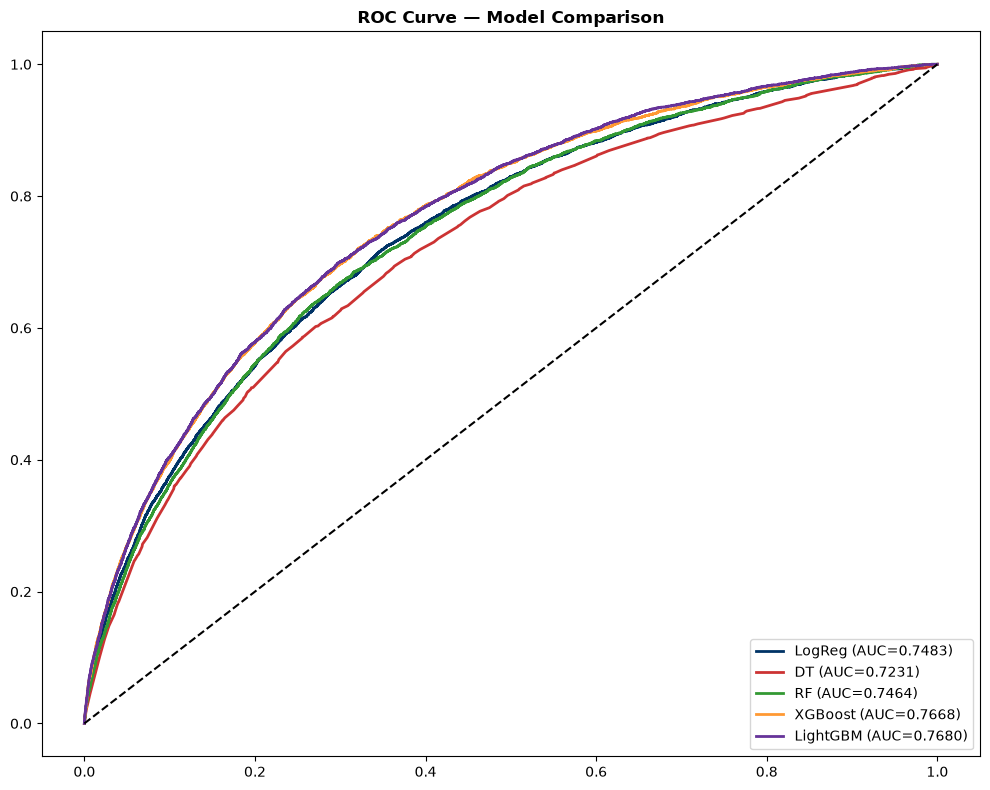

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#003366","#CC3333","#339933","#FF9933","#663399"]
probas = {"LogReg":p_lr,"DT":p_dt,"RF":p_rf}
if XGB_OK: probas["XGBoost"]=p_xgb
probas["LightGBM"]=p_lgb
for (n, p), c in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, c=c, lw=2, label=f"{n} (AUC={roc_auc_score(y_test,p):.4f})")
ax.plot([0,1],[0,1],"k--")
ax.legend(loc="lower right")
ax.set_title("ROC Curve — Model Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig(D("reports/figures/modeling_roc_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

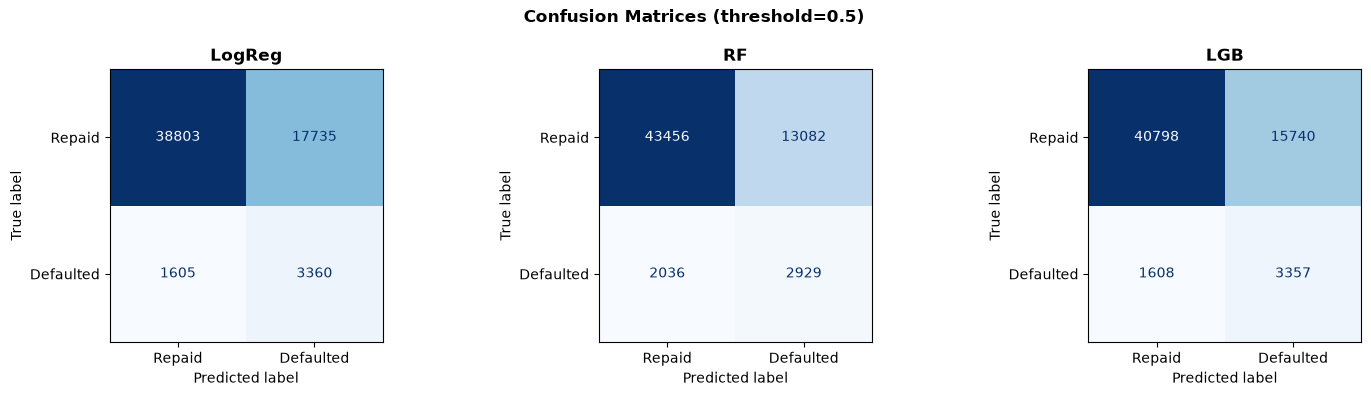

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (n, p) in zip(axes, [("LogReg",p_lr),("RF",p_rf),("LGB",p_lgb)]):
    yb = (p >= 0.5).astype(int)
    cm = confusion_matrix(y_test, yb)
    ConfusionMatrixDisplay(cm, display_labels=["Repaid","Defaulted"]).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(n, fontweight="bold")
    ax.grid(False)
plt.suptitle("Confusion Matrices (threshold=0.5)", fontweight="bold")
plt.tight_layout()
plt.savefig(D("reports/figures/modeling_confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Threshold Tuning (F2-Optimal)

In [12]:
best_name = res.iloc[0]["Model"]
pmap = {"LogReg":p_lr,"DT":p_dt,"RF":p_rf}
if XGB_OK: pmap["XGBoost"]=p_xgb
pmap["LightGBM"]=p_lgb
best_p = pmap[best_name]
print(f"Best model: {best_name}")

th = np.arange(0.01, 0.50, 0.005)
f2s, ps, rs = [], [], []
for t in th:
    yb = (best_p >= t).astype(int)
    p = precision_score(y_test, yb, zero_division=0)
    r = recall_score(y_test, yb, zero_division=0)
    d = 4*p + r
    f2s.append((5*p*r)/d if d > 0 else 0)
    ps.append(p); rs.append(r)
ix = np.argmax(f2s)
ot = th[ix]
print(f"Optimal threshold: {ot:.3f}")
print(f"F2={f2s[ix]:.4f}  P={ps[ix]:.4f}  R={rs[ix]:.4f}")

Best model: LightGBM


Optimal threshold: 0.485
F2=0.4317  P=0.1711  R=0.6971


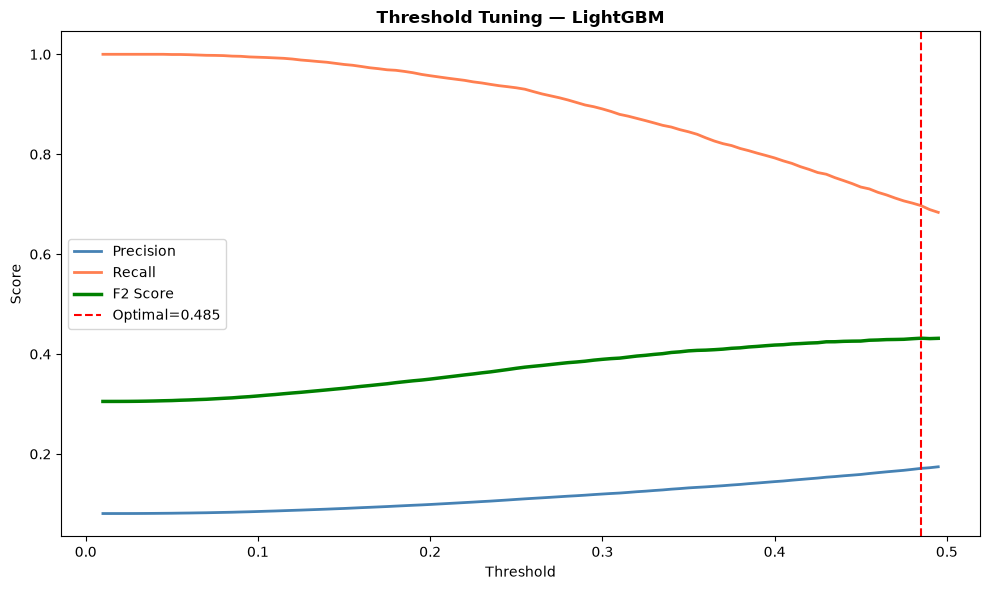

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(th, ps, label="Precision", c="steelblue", lw=2)
ax.plot(th, rs, label="Recall", c="coral", lw=2)
ax.plot(th, f2s, label="F2 Score", c="green", lw=2.5)
ax.axvline(x=ot, c="red", ls="--", label=f"Optimal={ot:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title(f"Threshold Tuning — {best_name}", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(D("reports/figures/modeling_threshold_tuning.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [14]:
ybf = (best_p >= ot).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, ybf).ravel()
print(f"=== {best_name} @ threshold {ot:.3f} ===")
print(f"AUC:           {roc_auc_score(y_test, best_p):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, best_p):.4f}")
print(f"Precision:     {precision_score(y_test, ybf):.4f}")
print(f"Recall:        {recall_score(y_test, ybf):.4f}")
print(f"F1: {f1_score(y_test, ybf):.4f}  F2: {f2s[ix]:.4f}")
print(f"Confusion: TN={tn} FP={fp} FN={fn} TP={tp}")

=== LightGBM @ threshold 0.485 ===
AUC:           0.7680
Avg Precision: 0.2580
Precision:     0.1711
Recall:        0.6971
F1: 0.2748  F2: 0.4317
Confusion: TN=39774 FP=16764 FN=1504 TP=3461


---
## 7. Save Best Model

In [15]:
obj_map = {"LogReg":lr,"DT":dt,"RF":rf}
if XGB_OK: obj_map["XGBoost"]=xgb_m
obj_map["LightGBM"]=lgb_m

artifact = {
    "model": obj_map[best_name],
    "model_name": best_name,
    "optimal_threshold": float(ot),
    "feature_names": list(X.columns),
    "test_metrics": {
        "auc": float(roc_auc_score(y_test, best_p)),
        "avg_precision": float(average_precision_score(y_test, best_p)),
        "precision": float(precision_score(y_test, ybf)),
        "recall": float(recall_score(y_test, ybf)),
        "f1": float(f1_score(y_test, ybf)),
        "f2": float(f2s[ix]),
        "optimal_threshold": float(ot),
    },
    "leaderboard": res,
}
joblib.dump(artifact, D("models/best_model.pkl"))
print(f"Saved: models/best_model.pkl")
print(f"Best: {best_name}, AUC={artifact["test_metrics"]["auc"]:.4f}")

Saved: models/best_model.pkl
Best: LightGBM, AUC=0.7680
